# Bil464 Ödev1 
## Şablon eşleştirme ile futbolcu tesipiti 

In [7]:
from pathlib import Path 

import cv2
import matplotlib.pyplot as plt
import numpy as np



# Veri seti
Bu ödevde tek sınıflı nesne tespiti problemi üzerine çalıştım. Tespit etmeye çalıştığım sınıf player sınıfı.

Train için 10 kırpılmış oyuncu şablonu bulunuyor
Validation için 200 player olan, 600 player olmayan görsel bulunuyor
Test için 200 player olan, 600 player olmayan görsel bulunuyor
Görüntülerin boyutu 256x256
Ön işlem olarak da griye çevirme uyguladım

In [8]:
templeteDir = Path("data/odevData/train/player")

validationPosDir = Path("data/odevData/validation/positive")

validationNegDir = Path("data/odevData/validation/negative")

testPosDir = Path("data/odevData/test/positive")

testNegDir = Path("data/odevData/test/negative")

print("Eğitim şablonu: ", len(list(templeteDir.glob("*.png"))))

print("Validation pozitif: ", len(list(validationPosDir.glob("*.jpg"))))

print("Validation negatif: ", len(list(validationNegDir.glob("*.jpg"))))

print("Test pozitif: ", len(list(testPosDir.glob("*.jpg"))))

print("Test negatif: ", len(list(testNegDir.glob("*.jpg"))))

Eğitim şablonu:  10
Validation pozitif:  200
Validation negatif:  600
Test pozitif:  200
Test negatif:  600


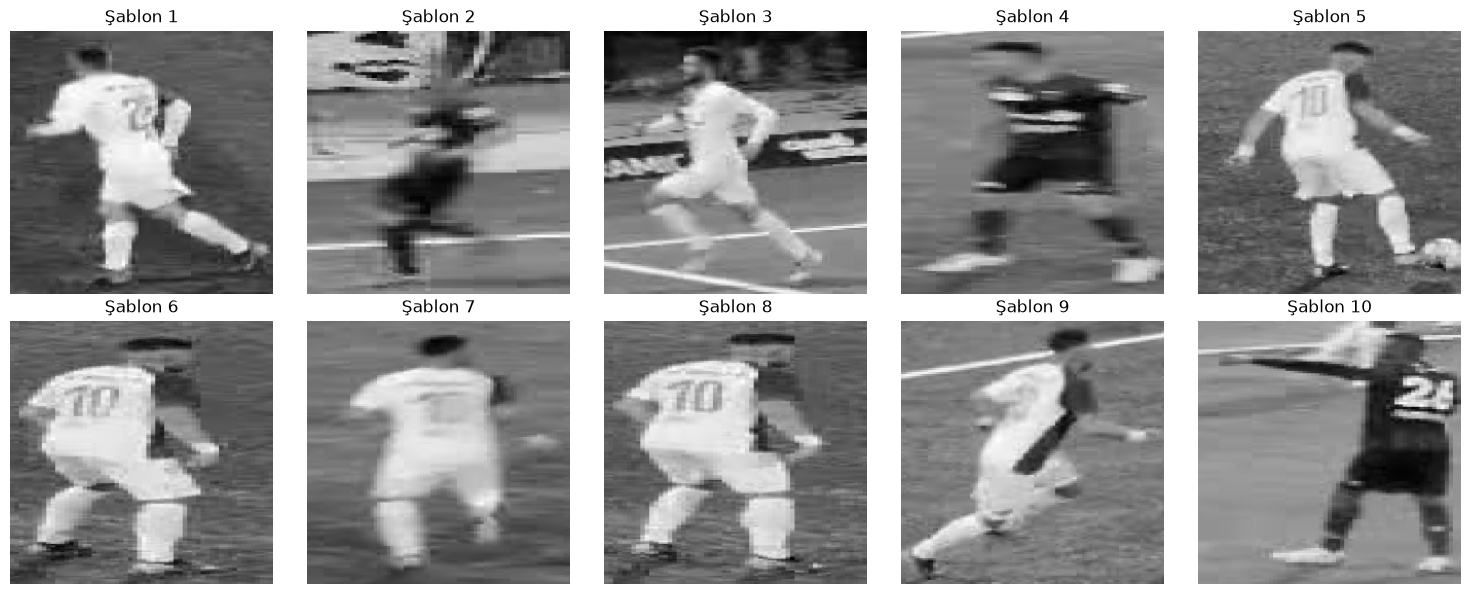

In [9]:
# train kırpılmış oyuncu şablonları
templatePaths = sorted(templeteDir.glob("*.png"))

plt.figure(figsize=(15, 6))

for index, templatePath in enumerate(templatePaths, start=1):
    template = cv2.imread(str(templatePath), cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 5, index)
    plt.imshow(template, cmap="gray")
    plt.title(f"Şablon {index}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Yöntem

Her validation ve test görüntüsü gri tonlamalı ve 256x256 boyutunda kullanıldı. Trainden 10 oyuncu görüntüsü şablon olarak alındı.
Her şablon şu ölçeklerle denendi:
256x256, 128x128, 64x64, 32x32


Her ölçek için şablon görüntü üzerinde kaydırıldı ve cv2.matchTemplate fonksiyonu TM_CCOEFF_NORMED yöntemi ile benzerlik skoru hesaplandı.

En yüksek benzerlik skoruna sahip bölge saklandı. Skopr eşleşme eşiğinden yüksekse görüntünün oyuncu olduğu kabul edildi.

Tahmin edilen bölgenin gerçek oyuncu kutusnu kapsama oranı hesaplandı ve alan eşiği ile karşılaştırıldı.



In [10]:
# Validation üzerinde 10 deney yapıldı.

import pandas as pd

validationResult = pd.DataFrame(
    [
        [1, 0.50, 8, 0.50, 1, 145, 455, 199, 0.8175, 0.0022, 0.0050, 0.0030],
        [2, 0.30, 2, 0.05, 70, 0, 600, 130, 0.9125, 0.1045, 0.3500, 0.1609],
        [3, 0.35, 8, 0.10, 36, 0, 600, 164, 0.9550, 0.0566, 0.1800, 0.0861],
        [4, 0.40, 16, 0.15, 14, 14, 586, 186, 0.9650, 0.0233, 0.0700, 0.0350],
        [5, 0.45, 4, 0.20, 4, 77, 523, 196, 0.8988, 0.0076, 0.0200, 0.0110],
        [6, 0.50, 32, 0.05, 70, 168, 432, 130, 0.7025, 0.1394, 0.3500, 0.1994],
        [7, 0.50, 8, 0.15, 14, 145, 455, 186, 0.8013, 0.0299, 0.0700, 0.0419],
        [8, 0.55, 2, 0.10, 36, 198, 402, 164, 0.7075, 0.0822, 0.1800, 0.1129],
        [9, 0.30, 4, 0.15, 14, 0, 600, 186, 0.9825, 0.0228, 0.0700, 0.0344],
        [10, 0.20, 2, 0.10, 36, 0, 600, 164, 0.9550, 0.0566, 0.1800, 0.0861],
    ],
    columns=[
        "Deney",
        "Eşleşme Eşiği",
        "Kayma Miktarı",
        "Alan Eşiği",
        "TP",
        "TN",
        "FP",
        "FN",
        "MSE",
        "Hassasiyet",
        "Geri Çağırma",
        "F1-Skor",
    ]
)

validationResult

,Deney,Eşleşme Eşiği,Kayma Miktarı,Alan Eşiği,TP,TN,FP,FN,MSE,Hassasiyet,Geri Çağırma,F1-Skor
0,1,0.50,8,0.50,1,145,455,199,0.8175,0.0022,0.005,0.0030
1,2,0.30,2,0.05,70,0,600,130,0.9125,0.1045,0.350,0.1609
2,3,0.35,8,0.10,36,0,600,164,0.9550,0.0566,0.180,0.0861
3,4,0.40,16,0.15,14,14,586,186,0.9650,0.0233,0.070,0.0350
4,5,0.45,4,0.20,4,77,523,196,0.8988,0.0076,0.020,0.0110
5,6,0.50,32,0.05,70,168,432,130,0.7025,0.1394,0.350,0.1994
6,7,0.50,8,0.15,14,145,455,186,0.8013,0.0299,0.070,0.0419
7,8,0.55,2,0.10,36,198,402,164,0.7075,0.0822,0.180,0.1129
8,9,0.30,4,0.15,14,0,600,186,0.9825,0.0228,0.070,0.0344
9,10,0.20,2,0.10,36,0,600,164,0.9550,0.0566,0.180,0.0861


In [11]:
# en iyi deney sonucu

bestResult = validationResult.loc[
    validationResult["F1-Skor"].idxmax()
]

bestResult

Deney              6.0000
Eşleşme Eşiği      0.5000
Kayma Miktarı     32.0000
Alan Eşiği         0.0500
TP                70.0000
TN               168.0000
FP               432.0000
FN               130.0000
MSE                0.7025
Hassasiyet         0.1394
Geri Çağırma       0.3500
F1-Skor            0.1994
Name: 5, dtype: float64

# En iyi hyperparametreler 

Validation üzerinde denenen hyperparametrelerden en yüksek f1 skoru 6. deneyde gözlendi.

Eşleşme eşiği: 0.50
Kayma miktarı: 32
Alan yüzdesi eşiği: 0.05
F1 skoru: 0.1994

bu hyperparametre değerleri test değerlendirmesi için kullanıldı.

In [12]:
testResult = {
    "TP": 74,
    "TN": 48,
    "FP": 552,
    "FN": 126,
    "Accuracy": 0.1525,
    "Precision": 0.1182,
    "Recall": 0.3700,
    "F1-Score": 0.1792,
    "MSE": 0.8475,
}

testResult

{'TP': 74,
 'TN': 48,
 'FP': 552,
 'FN': 126,
 'Accuracy': 0.1525,
 'Precision': 0.1182,
 'Recall': 0.37,
 'F1-Score': 0.1792,
 'MSE': 0.8475}

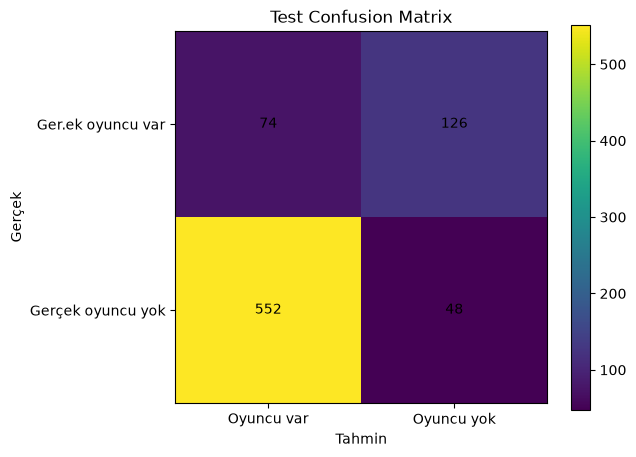

In [19]:
# Confusion Matrix 

confusionMatrix = np.array(
    [
        [74, 126],
        [552, 48]
    ]
)


plt.figure(figsize=(6, 5))
plt.imshow(confusionMatrix)

plt.xticks(
    [0, 1],
    ["Oyuncu var", "Oyuncu yok"]
)

plt.yticks(
    [0, 1],
    ["Ger.ek oyuncu var", "Gerçek oyuncu yok"]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusionMatrix[row, column],
            ha="center",
            va="center"
        )


plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

plt.title("Test Confusion Matrix")

plt.colorbar()
plt.show()

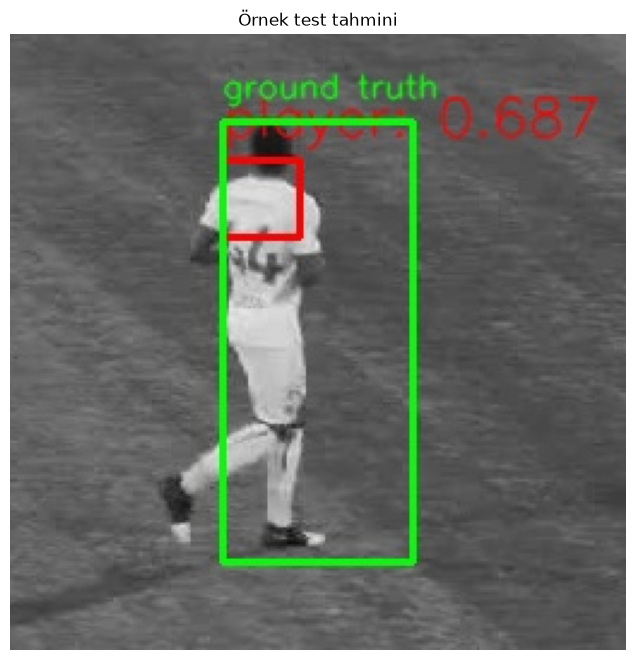

In [34]:
# Test görsel örneği

predictionPath = Path("finalTestPrediction.jpg")

predictionImage = cv2.imread(str(predictionPath))

predictionImage = cv2.cvtColor(predictionImage, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(predictionImage)
plt.title("Örnek test tahmini")
plt.axis("off")
plt.show()

# Sonuç 

Şablon eşleştirme yöntemi ile bazı oyuncuları doğru şekilde tespit edilebildi. Test veriseti için recall değeri 0.3700 olarak hesaplandı. Bununla birlikte, oyuncu içermeyen görüntülerde çok sayıda yanlış pozitif tahmin oluştu. Bu nedenle precision ve f1 skor değerleri düşük kaldı.

Oyuncuların farklı pozlar, formalar, görüntü ölçekleri ve kamera açılarına sahip olmaları şablon eşleştirme yönteminin performansını olumsuz etkilemiştir. Ayrıca resmin içindeki saha parçaları ve diğer görüntü parçaları bazı oyuncu şablonlarına benzerlik göstermiştir.

Sonuç olarak klasik şablon eşleştirme yönteminin futbol oyuncusu tespiti için sınırlı bir yöntem olduğunu gösteriyor.